In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import torch
import nibabel as nb

from tqdm.auto import tqdm
from os.path import join as pjoin

DATA7_PATH = "/System/Volumes/Data/data/data7"
projects_path = f"{DATA7_PATH}/network_control/projects"
sys.path.insert(1, projects_path)

import voxel_analysis as va
import torch_math_tools as tmt
import CAP_tools

NC_path = f"{DATA7_PATH}/network_control/projects/network_control"
sys.path.insert(1, NC_path)
import surface_mapping as sfm
import load
import plot

# PM Alternatives:

    [] individual ICA
    [] thresholded sparse matrix (threshold by r of like 0.2?)
    [] PCA and then correlate each PC with networks (FC and or spatial networks)

    [] iterative cluster assignment starting with "core functional connectivity", based on highest probability seeds

In [2]:
def get_cortex_data(full_data, cifti):
    pax = cifti.header.get_axis(1)
    slice_LUT = {structure: sl for structure, sl,_  in pax.iter_structures()}
    cortex_data_L = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_LEFT"]]
    cortex_data_R = full_data[:, slice_LUT["CIFTI_STRUCTURE_CORTEX_RIGHT"]]
    return np.hstack([cortex_data_L, cortex_data_R])

# Load Data

In [3]:
rs_dtseries_list_path = "/data/data7/network_control/scripts/_params/EC_CAP_analysis/EC_CAP_analysis_RS_fMRI_maps_dtseries_list.txt"

with open(rs_dtseries_list_path, "r") as f:
    dtseries_paths = f.read().strip().split()

subject_list = [path.split("/MNI")[0].split("/")[-1] for path in dtseries_paths]

In [4]:
cifti_path = dtseries_paths[0]

cifti = nb.load(cifti_path)
full_data = cifti.get_fdata()
cortex_data = get_cortex_data(full_data, cifti)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [5]:
priors_path = os.path.join(projects_path, "voxel_analysis/resources/priors.mat")

priors = scipy.io.loadmat(priors_path)
FC, spatial, network_labels, _ = priors["Priors"][0, 0]
network_labels = np.array([lab[0][0] for lab in network_labels])
FC, spatial = FC.T, spatial.T

### Load in all ciftis

In [6]:
# all_data = []
# for cifti_path in tqdm(dtseries_paths, desc="loading in all dtseries"):
#     cifti = nb.load(cifti_path)
#     full_data = cifti.get_fdata()
#     cortex_data = get_cortex_data(full_data, cifti)
#     all_data.append(cortex_data)
#     break

# Iterative cluster assignment

In [7]:
spatial.shape

(20, 59412)

<Axes: ylabel='Density'>

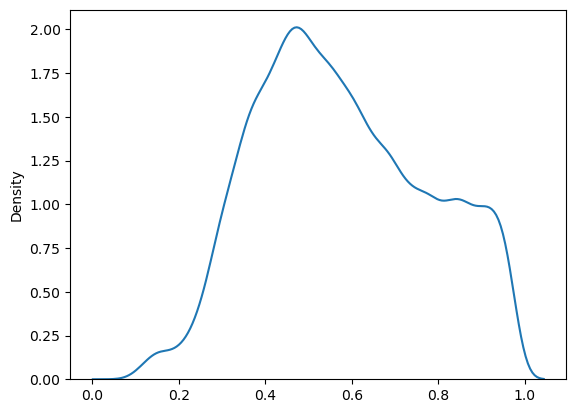

In [54]:
# high_confidence_seeds
sns.kdeplot(s_assign_conf)

In [9]:
s_assign = np.argmax(spatial, axis=0)
s_assign_conf = np.max(spatial, axis=0)

In [56]:
s_assign, s_assign_conf >= 0.75

(array([ 0, 10, 16, ...,  2,  2,  2]),
 array([ True, False, False, ..., False, False, False]))

In [70]:
network_vertices = [np.where((s_assign == i) & (s_assign_conf >= 0.75))[0] for i in range(20)]

In [88]:
unassigned_index = s_assign_conf < 0.75
unassigned_index = np.where(unassigned_index)[0]
unassigned_conf = s_assign_conf[unassigned_index]
ci = np.argsort(unassigned_conf)[::-1]

unassigned_index, unassigned_conf = unassigned_index[ci], unassigned_conf[ci]

In [94]:
network_labels[0]

'Default_Parietal'

In [190]:
def personalized_FC_prior(cortex_data, spatial, spatial_confidence=0.75, device="cpu"):
    """ """
    n_priors = spatial.shape[0]
    s_assign = np.argmax(spatial, axis=0)
    s_assign_conf = np.max(spatial, axis=0)
    network_vertices = [np.where((s_assign == i) & (s_assign_conf >= spatial_confidence))[0] for i in range(n_priors)]
    assert len(network_vertices) == n_priors, "lower spatial confidence for seeds"
    
    personal_FC = []

    ctd = torch.tensor(cortex_data, device=device)
    sact = torch.tensor(s_assign_conf, device=device)
    for i in tqdm(range(n_priors), leave=False, desc="Making Individual FC Priors"):
        net_i_index = network_vertices[i]
        w = sact[net_i_index] / sact[net_i_index].sum()
        d = torch_corr(ctd[:, net_i_index], ctd) * w.reshape(-1, 1)
        m = d.sum(axis=0).cpu().numpy()
        personal_FC.append(m)
    return np.array(personal_FC)

In [191]:
pFC_prior = personalized_FC_prior(cortex_data, spatial, device="cpu")

Making Individual FC Priors:   0%|          | 0/20 [00:00<?, ?it/s]

# Voxel Level Network Assignments

    [] Create noise model of voxel level data -> random noise + functional noise + various thought streams
        [] Build solver based off this model?

    [] decompose infomap method based off correlations into voxel levels
        []
        
    
    [] Dont think I decompose correlations between vertex and then spatial, into spatial directly but will see

        [] *** is mean of correlation the correlation of a mean: no its not.

        v = (1 x d)
        V = (n x d)
        C_i_j(vi, vj) = vi @ vj (1 x 1)
        C_i_all(vi, v) = vi @ V ( 1 x n)
        C_all_all(v, v) = V @ V (n x n)
        spatial = (20 x n)
        spatial_corr_i = spatial (20 x n) @ C_i_all.T (n x 1) = spatial @ (vi @ V).T = spatial @ (V.T @ vi)
        spatial_corr_all = spatial @ (V @ V)  = (20 x n) * (n x d ) * (d x n)

        reality:
        V: d x n
        S: b x n
        nS = S - Smean
        nC = C - Cmean
        Smean: b x 1
        Cmean: n x 1
        C = nV.T @ nV: (n x d) @ (n x d) = (V - Vmean).T @ (V - Vmean)
        
        sc = nS @ nC = nS @ (C - Cmean) = nS @ C - nS @ Cmean = 

In [102]:
def np_corr(x, y):
    """ """
    x, y = x.T, y.T
    x_demeaned = x - x.mean(axis=1, keepdims=True)
    y_demeaned = y - y.mean(axis=1, keepdims=True)

    x_norm = x_demeaned / np.sqrt(np.sum(x_demeaned ** 2, axis=1, keepdims=True))
    y_norm = y_demeaned / np.sqrt(np.sum(y_demeaned ** 2, axis=1, keepdims=True))
    return x_norm @ y_norm.T


def torch_corr(x, y):
    """ """
    x, y = x.T, y.T
    x_demeaned = x - x.mean(axis=1, keepdims=True)
    y_demeaned = y - y.mean(axis=1, keepdims=True)

    x_norm = x_demeaned / torch.sqrt(torch.sum(x_demeaned ** 2, axis=1, keepdims=True))
    y_norm = y_demeaned / torch.sqrt(torch.sum(y_demeaned ** 2, axis=1, keepdims=True))
    return x_norm @ y_norm.T

In [221]:
def block_corr(cortex_data, spatial, FC, personal_FC=False, device="mps", bs = 2000, leave=False, threshold=0.25):
    """ """
    if personal_FC:
        FC_prior = personalized_FC_prior(cortex_data, spatial, device="cpu")
    else:
        FC_prior = FC
    
    devp = dict(device=device)
    spatial = torch.tensor(spatial.astype("float32"), **devp)
    FC_prior = torch.tensor(FC_prior.astype("float32"), **devp)
    cortex_data = torch.tensor(cortex_data.astype("float32"), **devp)
    
    spatial_corr = -1 * torch.ones(spatial.shape[::-1], **devp)
    fc_corr = -1 * torch.ones(spatial.shape[::-1], **devp)

    n_blocks = int(np.ceil(spatial.shape[1] / bs))
    c = torch.tensor(0, **devp)
    threshold = - np.inf if threshold is None else threshold
    threshold = torch.tensor(threshold, **devp)
    for i in tqdm(range(n_blocks), leave=leave):
        sl = slice(i * bs, (i + 1) * bs)

        z = torch_corr(cortex_data[:, sl], cortex_data)
        z[z <= threshold] = 0
        c += torch.count_nonzero(z > 0)
        spatial_corr[sl, :] = torch_corr(z.T, spatial.T)
        fc_corr[sl, :] = torch_corr(z.T, FC_prior.T)
    s = cortex_data.shape[1]
    print(c, c / s ** 2)
    return spatial_corr.cpu().numpy(), fc_corr.cpu().numpy()

In [223]:
spc, fpc = block_corr(cortex_data, spatial, FC, device="cpu", threshold=0.25, personal_FC=False)

  0%|          | 0/30 [00:00<?, ?it/s]

tensor(1832623881) tensor(0.5192)


In [10]:
cortex_data.shape, FC.shape

((1488, 59412), (20, 59412))

In [164]:
V = cortex_data.T # (n x TRs)
Vc = V - V.mean(axis=0)
Vn = (V - V.mean(axis=0)) / np.std(V, axis=0)

FCt = FC.T # (n x d)
FCtc = FCt - FCt.mean(axis=0) # subtracts d means
FCtn = FCtc / np.std(FCtc, axis=0) # devides by d stds

In [167]:
fpc[0]

array([ 0.12302805,  0.0936514 ,  0.08324532,  0.06595565, -0.04899694,
       -0.058829  , -0.04736097, -0.03724001, -0.01081283, -0.08489688,
       -0.0598464 , -0.00767517,  0.00553162, -0.09124274,  0.0420451 ,
       -0.03647114, -0.03818007, -0.04021918, -0.06275751, -0.05847802],
      dtype=float32)

In [201]:
FCV = (Vn.T @ FCtn) / Vn.shape[0]

In [203]:
FCV.shape

(1488, 20)

In [175]:
FCV = np_corr(FCt, V).T
FCV.shape

(1488, 20)

In [223]:
# np.argmax(np_corr(V.T, FCV), axis=1)
z = V @ FCV 

In [227]:
scipy.stats.pearsonr(z[:, 0], fpc[:, 0])

PearsonRResult(statistic=0.8494384161551551, pvalue=0.0)

In [218]:
np.argmax(fpc, axis=1)

array([ 0, 17, 16, ...,  8,  2,  8])

In [195]:
z = (FCtn.T @ Vn) / FCtn.shape[0]
z[0]

array([ 0.00743424,  0.0513523 ,  0.09667009, ..., -0.07174035,
       -0.10832052, -0.12307147])

In [159]:
np_corr(FCn.T, V)[0]

array([ 0.00743424,  0.0513523 ,  0.09667009, ..., -0.07174035,
       -0.10832052, -0.12307147])

In [150]:
np_corr(FCtn, Vn)[0]

array([ 0.00743424,  0.0513523 ,  0.09667009, ..., -0.07174035,
       -0.10832052, -0.12307147])

In [12]:
z = Vn.T @ FCn

In [13]:
zo = np_corr(FC.T, FC.T)

In [14]:
zn = FCn.T @ FCn

In [15]:
FC.shape

(20, 59412)

In [17]:
scipy.stats.pearsonr(FC[0], FC[1])

PearsonRResult(statistic=0.8746333934650706, pvalue=0.0)

In [93]:
np_corr(FC.T, FC.T)[0]

array([ 1.        ,  0.87463339,  0.6729074 ,  0.5535188 , -0.38458756,
       -0.49964973, -0.33723395, -0.33917493, -0.15531208, -0.79200483,
       -0.52490704,  0.11877176,  0.11764631, -0.74179367,  0.16143883,
       -0.25211872, -0.27437682, -0.27360826, -0.42303097, -0.46528813])

In [94]:
np.corrcoef(FC)[0]

array([ 1.        ,  0.87463339,  0.6729074 ,  0.5535188 , -0.38458756,
       -0.49964973, -0.33723395, -0.33917493, -0.15531208, -0.79200483,
       -0.52490704,  0.11877176,  0.11764631, -0.74179367,  0.16143883,
       -0.25211872, -0.27437682, -0.27360826, -0.42303097, -0.46528813])

In [95]:
FC.mean(axis=1).shape

(20,)

In [96]:
FCc.shape, FC.shape, FCn.shape

((20, 59412), (20, 59412), (20, 59412))

In [97]:
FCc = (FC - FC.mean(axis=1, keepdims=True))
np.corrcoef(FCc)[0]
FCn = FCc / np.std(FC, axis=1, keepdims=True)
np.corrcoef(FCn)[0]

array([ 1.        ,  0.87463339,  0.6729074 ,  0.5535188 , -0.38458756,
       -0.49964973, -0.33723395, -0.33917493, -0.15531208, -0.79200483,
       -0.52490704,  0.11877176,  0.11764631, -0.74179367,  0.16143883,
       -0.25211872, -0.27437682, -0.27360826, -0.42303097, -0.46528813])

In [ ]:
(FCn @ FCn.T) / FCn.shape[1];

In [530]:
sparseC = tmt.matrix.ThresholdCorrelator.run(cortex_data, threshold=0.25,
                                          block_size=5000, symmetric=True, skip_diagonal=True)

ThresholdCorrelator Block Analysis:   0%|          | 0/1950.0 [00:00<?, ?it/s]

In [321]:
for personal_FC in [False, True]:
    for threshold in [0.25, 0.5, None]:
        # threshold = 0.25
        # personal_FC = False
        threshold_tag = "" if threshold is None else f"_T{threshold*100:0.0f}"
        threshold_tag
        prior_tag = "_pFC" if personal_FC else ""

        for subject, cifti_path in zip(subject_list, tqdm(dtseries_paths, desc="creating voxel corr maps")):
        # for subject in tqdm(subject_list, desc="creating voxel corr maps"):
        #     cifti_path = f"~/local/{subject}_RS.dtseries.nii"
            fc_path = f"scratch/{subject}_vertex_fc_corr{threshold_tag}{prior_tag}.npy"
            spatial_path = f"scratch/{subject}_vertex_spatial_corr{threshold_tag}{prior_tag}.npy"
            
            if os.path.exists(fc_path) and os.path.exists(spatial_path):
                continue
            
            cifti = nb.load(cifti_path)
            full_data = cifti.get_fdata()
            full_data = full_data[np.isnan(full_data).sum(axis=1) == 0]
        
            cortex_data = get_cortex_data(full_data, cifti)
            spc, fcc = block_corr(cortex_data, spatial, FC, device="cpu", threshold=threshold, personal_FC=personal_FC)
            np.save(fc_path, fcc)
            np.save(spatial_path, spc)

creating voxel corr maps:   0%|          | 0/54 [00:00<?, ?it/s]

creating voxel corr maps:   0%|          | 0/54 [00:00<?, ?it/s]

creating voxel corr maps:   0%|          | 0/54 [00:00<?, ?it/s]

creating voxel corr maps:   0%|          | 0/54 [00:00<?, ?it/s]

creating voxel corr maps:   0%|          | 0/54 [00:00<?, ?it/s]

creating voxel corr maps:   0%|          | 0/54 [00:00<?, ?it/s]

In [328]:
threshold = 0.25
# threshold = None
personal_FC = True
threshold_tag = "" if threshold is None else f"_T{threshold*100:0.0f}"
threshold_tag
prior_tag = "_pFC" if personal_FC else ""

fcc_all = []
spc_all = []
valid_subjects = []
for subject in subject_list:

    if subject in ["ec_08_0015", "ec_00_0078", "ec_08_0028"]:
        continue
        
    fc_path = f"scratch/{subject}_vertex_fc_corr{threshold_tag}{prior_tag}.npy"
    spatial_path = f"scratch/{subject}_vertex_spatial_corr{threshold_tag}{prior_tag}.npy"
    
    if not (os.path.exists(fc_path) and os.path.exists(spatial_path)):
        continue

    fcc = np.load(fc_path)
    spc = np.load(fc_path)
    fcc_all.append(fcc)
    spc_all.append(spc)
    valid_subjects.append(subject)

fcc_all = np.array(fcc_all)
spc_all = np.array(spc_all)
combined_all = fcc_all * spc_all
valid_subjects = np.array(valid_subjects)

In [329]:
spc_all = np.array([spatial.T] * len(spc_all))
len(spc_all)

51

In [330]:
df_all = []
for method, corr_all in zip(["spatial", "fc", "combined"], [spc_all, fcc_all, combined_all]):
    labels = np.argmax(corr_all, axis=-1)
    counts = np.array([np.bincount(label_i, minlength=20) for label_i in labels])
    sizes = counts / counts.sum(axis=1, keepdims=True)

    df_i = pd.DataFrame(sizes, columns=network_labels[:-1])
    df_i["subject"] = valid_subjects
    df_i["size_method"] = method
    df_all.append(df_i)

df_all = pd.concat(df_all)
df_all = df_all.melt(id_vars=["subject", "size_method"], var_name="network", value_name="size")
df_all["group"] = np.array(["hc", "szp"])[df_all["subject"].str.contains("_08_") * 1]

cdf = df_all.query("size_method == 'combined'")
sdf = df_all.query("size_method == 'spatial'")
fdf = df_all.query("size_method == 'fc'")
cdf

,subject,size_method,network,size,group
102,ec_00_0001,combined,Default_Parietal,0.074362,hc
103,ec_00_0005,combined,Default_Parietal,0.094678,hc
104,ec_00_0013,combined,Default_Parietal,0.070205,hc
105,ec_00_0018,combined,Default_Parietal,0.081583,hc
106,ec_00_0023,combined,Default_Parietal,0.053861,hc
...,...,...,...,...,...
3055,ec_08_0055,combined,SomatoCognitiveAction,0.038898,szp
3056,ec_08_0057,combined,SomatoCognitiveAction,0.024961,szp
3057,ec_08_0060,combined,SomatoCognitiveAction,0.014963,szp
3058,ec_08_0061,combined,SomatoCognitiveAction,0.040413,szp


<Axes: xlabel='size', ylabel='network'>

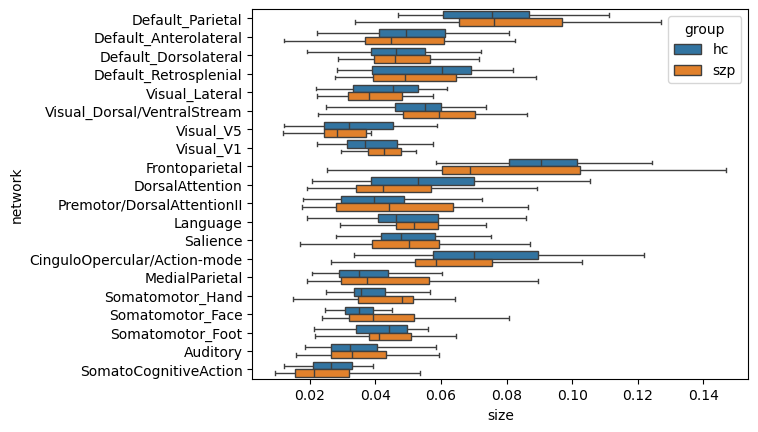

In [332]:
sns.boxplot(data=fdf, y="network", x="size", hue="group", showfliers=False)

In [ ]:
full_cdf = cdf.pivot(index=['subject', "group"], columns="network", values='size').reset_index()
szp_df = full_cdf.loc[full_cdf["group"] == "szp"]
hc_df = full_cdf.loc[full_cdf["group"] != "szp"]

t_s, p_s = scipy.stats.ttest_ind(szp_df[network_labels[:-1]], hc_df[network_labels[:-1]])

sig_index = p_s < 0.05
network_labels[:-1][sig_index], p_s[sig_index]

# Get Vertex Surface Area

In [310]:
import nibabel as nb
import numpy as np

def get_vertex_surface_area(surface_file):
    # Load the GIFTI surface file
    gii = nb.load(surface_file)
    
    # Get the vertices and faces
    vertices = gii.darrays[0].data
    faces = gii.darrays[1].data

    # Compute surface area for each triangle
    tri_vertices = vertices[faces]
    a = tri_vertices[:, 1] - tri_vertices[:, 0]
    b = tri_vertices[:, 2] - tri_vertices[:, 0]
    cross_product = np.cross(a, b)
    triangle_areas = 0.5 * np.linalg.norm(cross_product, axis=1)

    # Distribute triangle areas to vertices
    vertex_areas = np.zeros(vertices.shape[0])
    for i in range(3):
        np.add.at(vertex_areas, faces[:, i], triangle_areas / 3)

    return vertex_areas

# Example usage:
# surface_file = "path/to/left_surface.surf.gii"
# vertex_areas = get_vertex_surface_area(surface_file)


In [311]:
L_surf_file = "/System/Volumes/Data/data/data6/earlycort_7114/ec_00_0005/MNINonLinear/fsaverage_LR32k/ec_00_0005.L.midthickness.32k_fs_LR.surf.gii"
R_surf_file = "/System/Volumes/Data/data/data6/earlycort_7114/ec_00_0005/MNINonLinear/fsaverage_LR32k/ec_00_0005.R.midthickness.32k_fs_LR.surf.gii"
generic_surf_file = "/data/data4/earlycort_7114/{subject}/MNINonLinear/fsaverage_LR32k/{subject}.{side}.midthickness.32k_fs_LR.surf.gii"

In [312]:
L_surf_files = [generic_surf_file.format(subject=subj.split("_16")[0], side="L") for subj in valid_subjects]
R_surf_files = [generic_surf_file.format(subject=subj.split("_16")[0], side="R") for subj in valid_subjects]

L_SA_all = np.expand_dims(np.array([get_vertex_surface_area(sf) for sf in L_surf_files]), -1)
R_SA_all = np.expand_dims(np.array([get_vertex_surface_area(sf) for sf in R_surf_files]), -1)

In [313]:
labels_all = np.argmax(fcc_all, axis=-1)
labels_all = np.argmax(fcc_all * spc_all, axis=-1)

label_all_values = CAP_tools.utils.cifti_map(None, labels_all, cifti)
n_subjs = len(valid_subjects)


compare_table = np.tile(np.arange(20), (n_subjs, 1, 1))

In [314]:
R_sizes_all = R_SA_all * (label_all_values["right"].reshape(n_subjs, -1, 1) == compare_table)
L_sizes_all = L_SA_all * (label_all_values["left"].reshape(n_subjs, -1, 1) == compare_table)
sizes_all = R_sizes_all + L_sizes_all
size_frac_all = sizes_all / sizes_all.sum(axis=(1, 2), keepdims=True)

In [315]:
df = pd.DataFrame(size_frac_all.sum(axis=1), columns=network_labels[:-1])
df["subject"] = valid_subjects

df = df.melt(id_vars=["subject"], var_name="network", value_name="size")
df["group"] = np.array(["hc", "szp"])[df["subject"].str.contains("_08_") * 1]

<Axes: xlabel='size', ylabel='network'>

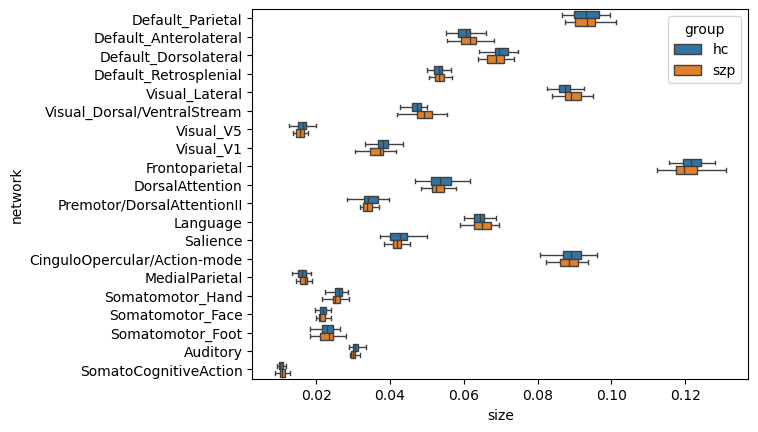

In [316]:
sns.boxplot(data=df, y="network", x="size", hue="group", showfliers=False)

In [302]:
full_cdf = df.pivot(index=['subject', "group"], columns="network", values='size').reset_index()
szp_df = full_cdf.loc[full_cdf["group"] == "szp"]
hc_df = full_cdf.loc[full_cdf["group"] != "szp"]

t_s, p_s = scipy.stats.ttest_ind(szp_df[network_labels[:-1]], hc_df[network_labels[:-1]])

sig_index = p_s < 0.05
print(network_labels[:-1][sig_index])
print(p_s[sig_index])

szp_m_sizes = szp_df[network_labels[:-1]].mean()
hc_m_sizes = hc_df[network_labels[:-1]].mean()
size_ratio = szp_m_sizes / hc_m_sizes

size_ratio[sig_index], size_ratio

['Visual_Lateral' 'Visual_Dorsal/VentralStream']
[0.00461677 0.01524006]


(network
 Visual_Lateral                 1.040486
 Visual_Dorsal/VentralStream    1.057564
 dtype: float64,
 network
 Default_Parietal                0.983405
 Default_Anterolateral           1.020802
 Default_Dorsolateral            0.970638
 Default_Retrosplenial           0.995859
 Visual_Lateral                  1.040486
 Visual_Dorsal/VentralStream     1.057564
 Visual_V5                       0.955776
 Visual_V1                       0.953327
 Frontoparietal                  0.972167
 DorsalAttention                 1.023127
 Premotor/DorsalAttentionII      0.980246
 Language                        1.014904
 Salience                        0.981720
 CinguloOpercular/Action-mode    1.003145
 MedialParietal                  1.017208
 Somatomotor_Hand                0.998696
 Somatomotor_Face                0.988455
 Somatomotor_Foot                1.048642
 Auditory                        0.986258
 SomatoCognitiveAction           1.049303
 dtype: float64)

# Demographic Associations

In [267]:
demo_path = "/data/data7/network_control/resources/excel/GBU_tasit_demographics_all.tsv"

pdf = pd.read_csv(demo_path, sep="\t")
pdf["subject"] = pdf["PCode"]
pdf = pdf.merge(full_cdf, on="subject").reset_index(drop=True)

zpdf = pdf.query("group == 'szp'").reset_index(drop=True)

In [268]:
cols = ['AGE', 'Age at test', 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
       'Edinburgh score', 'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
       'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
       'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore',
       'highest grade achieved',
       'Default_Parietal', 'Default_Anterolateral', 'Default_Dorsolateral',
       'Default_Retrosplenial', 'Visual_Lateral',
       'Visual_Dorsal/VentralStream', 'Visual_V5', 'Visual_V1',
       'Frontoparietal', 'DorsalAttention', 'Premotor/DorsalAttentionII',
       'Language', 'Salience', 'CinguloOpercular/Action-mode',
       'MedialParietal', 'Somatomotor_Hand', 'Somatomotor_Face',
       'Somatomotor_Foot', 'Auditory', 'SomatoCognitiveAction', 'Noise']

cols = network_labels[:-1][sig_index]

In [269]:
dem_vars = ["AGE", 'CPZTotal', 'ER40_Total', 'ER40_Total_Per',
           'Edinburgh score', 'Gender', 'PANSS_Neg_3F','PANSS_Pos_3F', 'PANSS_Tot_3F',
           'PSIComposite_ScaledScore', 'Participant SES', 'ProcessingSpeedIndex', 'Sarcasm_total',
           'TotalCorrect', 'TotalLiesCorrect', 'TotalSarcCorrect', 'WRAT_ScaledScore']

size_vars = network_labels[:-1][sig_index]
alpha = 0.05
print("Szp")
sig_clin_vars = []
sig_size_vars = []
for var1 in dem_vars:
    for var2 in size_vars:
        
        cdf = zpdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            sig_clin_vars.append(var1)
            sig_size_vars.append(var2)
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.2f}")


print("\n\nHealthy Controls")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf.query("group == 'HC'")[[var1, var2]].dropna() 
        if len(cdf) < 2:
            continue
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.2f}")


print("\n\nAll Subjects")
for var1 in dem_vars:
    for var2 in size_vars:
        cdf = pdf[[var1, var2]].dropna()        
        r, p = scipy.stats.pearsonr(cdf[var1], cdf[var2])
        if p < alpha:
            s = f"{var1} - {var2}"
            print(s + f"{' ' * (35 - len(s))}:: R = {r:.02f} {p:0.2f}")

Szp
AGE - Visual_Dorsal/VentralStream  :: R = 0.52 0.01
Edinburgh score - Auditory         :: R = -0.50 0.01
ProcessingSpeedIndex - Visual_Lateral:: R = -0.41 0.04
WRAT_ScaledScore - Visual_V1       :: R = -0.47 0.02


Healthy Controls


All Subjects
AGE - Default_Parietal             :: R = 0.41 0.01
AGE - Default_Retrosplenial        :: R = -0.36 0.02
AGE - Visual_Dorsal/VentralStream  :: R = 0.41 0.01
Edinburgh score - Auditory         :: R = -0.41 0.01
Gender - Default_Retrosplenial     :: R = -0.40 0.01
Gender - Visual_V1                 :: R = -0.32 0.04
PSIComposite_ScaledScore - Default_Parietal:: R = -0.35 0.02
PSIComposite_ScaledScore - Visual_Lateral:: R = -0.36 0.02
ProcessingSpeedIndex - Default_Parietal:: R = -0.35 0.02
ProcessingSpeedIndex - Visual_Lateral:: R = -0.36 0.02
TotalCorrect - Visual_Lateral      :: R = -0.34 0.02
TotalSarcCorrect - Visual_Lateral  :: R = -0.32 0.03


In [353]:
spatial.shape, cortex_data.shape

((20, 59412), (1488, 59412))

In [365]:
V = cortex_data

nV = (V - np.mean(V, axis=0)) / np.std(V, axis=0)

np_corr(nV, nV)

KeyboardInterrupt: 

In [354]:
spv = np_corr(spatial.T, cortex_data.T)
spv_corr = np_corr(spv.T, cortex_data).T

In [355]:
scipy.stats.spearmanr(spc.ravel(), spv_corr.ravel())

SignificanceResult(statistic=0.9624085001054768, pvalue=0.0)

In [217]:
spc_labels = np.argmax(spc, axis=1)
spv_corr_labels = np.argmax(spv_corr, axis=1)

<Axes: >

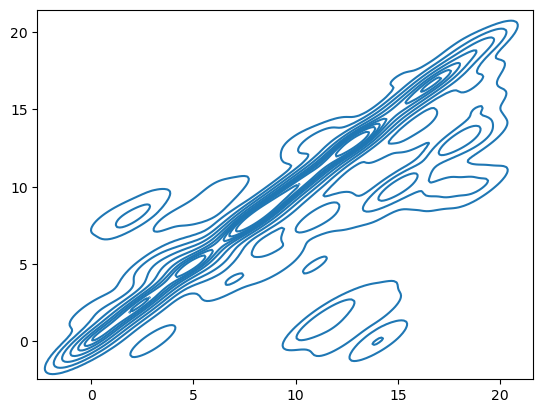

In [219]:
sns.kdeplot(x=spv_corr_labels, y=spc_labels)

In [222]:
spc, spv_corr

(array([[ 0.27457488,  0.03876472,  0.14063741, ...,  0.12281489,
          0.02313065,  0.00981659],
        [-0.20321736, -0.19390464, -0.30619532, ...,  0.2839689 ,
          0.1435334 ,  0.16434394],
        [-0.24980241, -0.26344973, -0.41437438, ...,  0.21306548,
          0.12911859,  0.18113934],
        ...,
        [ 0.09879132,  0.09548211,  0.41085783, ...,  0.01068629,
         -0.0524584 , -0.06407341],
        [ 0.12500131,  0.04419648,  0.40606615, ...,  0.01531622,
         -0.02684187, -0.06558671],
        [ 0.09324808,  0.05818895,  0.40689778, ...,  0.04436585,
         -0.04206701, -0.04138795]], dtype=float32),
 array([[ 0.24315277,  0.03682774,  0.08521667, ...,  0.12913984,
          0.03896032,  0.01109903],
        [-0.15433501, -0.16692847, -0.23115125, ...,  0.30384407,
          0.18557409,  0.18086215],
        [-0.2553168 , -0.28809775, -0.35496301, ...,  0.25064991,
          0.20315586,  0.24763523],
        ...,
        [ 0.12905964,  0.14382152,  0.4

In [7]:
def vertex_plot(array, ax=None):
    values = CAP_tools.utils.cifti_map(None, array, cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, cmap=plt.cm.coolwarm, ax=ax)

In [54]:
devp = dict(device="cpu")
tc_data = torch.tensor(cortex_data.astype("float32"), **devp)

In [9]:
%timeit torch_corr(tc_data[:, 0:10], tc_data[:, 1:])

20 ms ± 8.05 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
z.shape

(1, 59412)

In [223]:
def voxel_network_assignment(cortex_data, spatial, FC, device="mps"):
    """ """
    devp = dict(device=device)
    spatial = torch.tensor(spatial.astype("float32"), **devp)
    FC = torch.tensor(FC.astype("float32"), **devp)
    cortex_data = torch.tensor(cortex_data.astype("float32"), **devp)
    
    spatial_labels = torch.full((spatial.shape[1], ), fill_value=-1, **devp)
    fc_labels = torch.full((spatial.shape[1],), fill_value=-1, **devp)
    combined_labels = torch.full((spatial.shape[1],), fill_value=-1, **devp)
    
    sl = slice(0, 10)
    sl = slice(0, 1)
    
    bs = 1000
    n_blocks = int(np.ceil(spatial.shape[1] / bs))
    for i in tqdm(range(n_blocks)):
        sl = slice(i * bs, (i + 1) * bs)
        # z = np_corr(cortex_data[:, sl], cortex_data[:, :])
        z = torch_corr(cortex_data[:, sl], cortex_data)
        spatial_corr = torch_corr(z.T, spatial.T)
        fc_corr = torch_corr(z.T, FC.T)
        spatial_labels[sl] = torch.argmax(spatial_corr, axis=1)
        fc_labels[sl] = torch.argmax(fc_corr, axis=1)
        combined_labels[sl] = torch.argmax(fc_corr * spatial_corr, axis=1)

    return fc_labels.cpu().numpy(), spatial_labels.cpu().numpy(), combined_labels.cpu().numpy()

In [126]:
fc_labels, spatial_labels, combined_labels = voxel_network_assignment(cortex_data, spatial, FC, device="cpu")

  0%|          | 0/60 [00:00<?, ?it/s]

In [129]:
def get_network_sizes(labels, network_labels):
    """ """
    un_labels, un_counts = np.unique(fc_labels, return_counts=True)

    return network_labels[un_labels], un_counts / np.sum(un_counts)

In [131]:
fc_nets, fc_sizes = get_network_sizes(fc_labels, network_labels)

<BarContainer object of 20 artists>

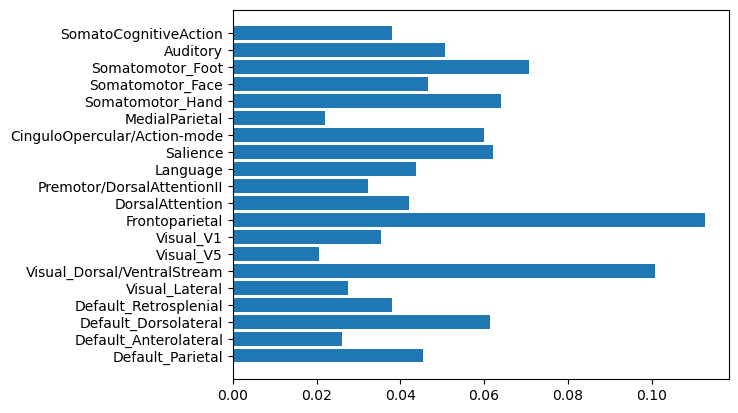

In [135]:
plt.barh(fc_nets, fc_sizes)
# plt.barh(fc_nets + 1, fc_sizes)

In [127]:
z1 = np.random.randn(len(fc_labels)) / 10
z2 = np.random.randn(len(fc_labels)) / 10

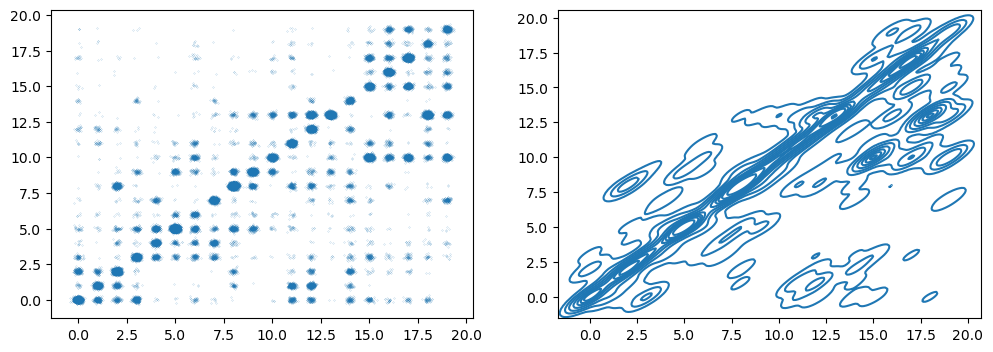

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(x=fc_labels, y=spatial_labels, bw_method=0.1, ax=axes[1])
axes[0].scatter(fc_labels + z1, spatial_labels + z2, s=0.01)

<BarContainer object of 20 artists>

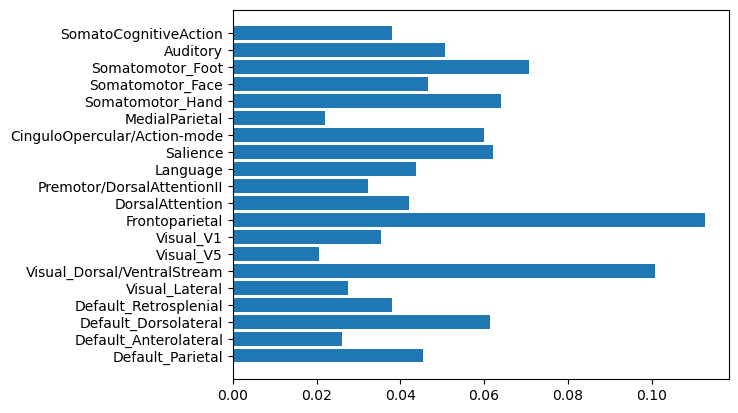

In [82]:
fc_ul, fc_uc = np.unique(fc_labels, return_counts=True)

plt.barh(network_labels[fc_ul], fc_uc / np.sum(fc_uc))

In [20]:
network_labels[np.argmax(np_corr(z.T, FC.T))]

'Default_Parietal'

# ICA 

In [18]:
from sklearn.decomposition import FastICA

def run_ica(cifti, n_components=2):
    """ """
    full_data = cifti.get_fdata()
    full_data = full_data[np.isnan(full_data).sum(axis=1) == 0]
    cortex_data = get_cortex_data(full_data, cifti)
    ica = FastICA(n_components=n_components, random_state=0, whiten='unit-variance')
    dt = ica.fit_transform(cortex_data.T)
    return dt

In [19]:
dt = run_ica(cifti)

In [23]:
for subject, cifti_path in zip(subject_list, tqdm(dtseries_paths)):
    save_path = f"scratch/{subject}_ica_comps.npy"
    if os.path.exists(save_path):
        continue

    cifti = nb.load(cifti_path)
    dt = run_ica(cifti, n_components=100)
    np.save(save_path, dt)

  0%|          | 0/54 [00:00<?, ?it/s]

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


KeyboardInterrupt: 

In [306]:
ls scratch

ec_00_0001_ica_comps.npy


In [286]:


transformer = FastICA(n_components=100, random_state=0, whiten='unit-variance')

In [287]:
Xt = transformer.fit(cortex_data.T)

In [168]:
vars(Xt);

In [169]:
ct = get_cortex_data(Xt.components_, cifti)
ct = ct / ct.std(axis=1, keepdims=True)
ct = np.clip(ct, -4, 4)

In [170]:
dt = Xt.transform(cortex_data.T).T

In [171]:
dt.shape

(50, 59412)

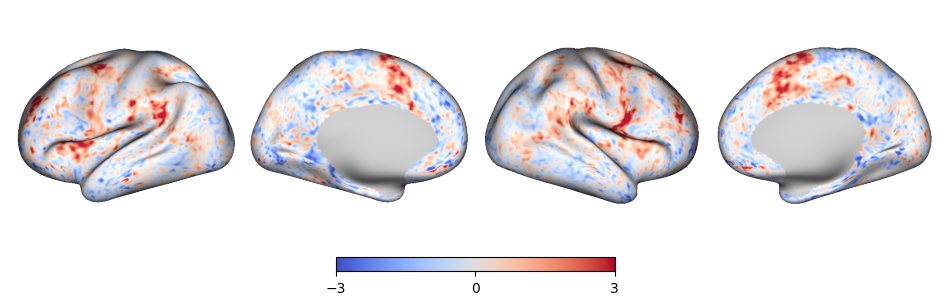

In [176]:
ica_values = CAP_tools.utils.cifti_map(None, np.clip(dt[10], -3, 3), cifti)

fig, ax = plt.subplots(figsize=(12, 4))
ax, _ = sfm.surface_plot(ica_values, cmap=plt.cm.coolwarm, ax=ax)

In [178]:
FC.shape, dt.shape

((20, 59412), (50, 59412))

<BarContainer object of 20 artists>

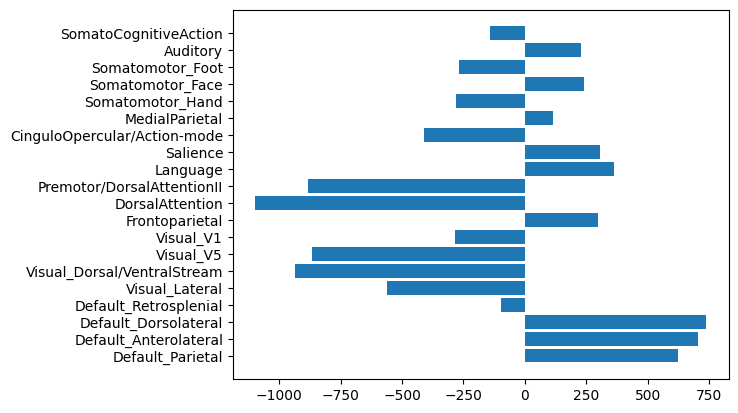

In [211]:
plt.barh(network_labels[:-1], np.sum(FC * dt[5], axis=1))

In [279]:
z = dt @ FC.T
# z = dt @ spatial.T

network_labels[np.argmax(z, axis=1)]

array(['Default_Parietal', 'Default_Parietal',
       'CinguloOpercular/Action-mode', 'Frontoparietal', 'MedialParietal',
       'Default_Dorsolateral', 'Default_Dorsolateral', 'Auditory',
       'Premotor/DorsalAttentionII', 'Somatomotor_Hand',
       'CinguloOpercular/Action-mode', 'MedialParietal',
       'SomatoCognitiveAction', 'Somatomotor_Hand', 'Salience',
       'CinguloOpercular/Action-mode', 'Visual_Dorsal/VentralStream',
       'CinguloOpercular/Action-mode', 'Default_Dorsolateral', 'Salience',
       'Visual_V1', 'Premotor/DorsalAttentionII',
       'Premotor/DorsalAttentionII', 'MedialParietal',
       'Default_Dorsolateral', 'Salience', 'Salience',
       'Default_Dorsolateral', 'SomatoCognitiveAction',
       'Default_Dorsolateral', 'Visual_V5',
       'CinguloOpercular/Action-mode', 'Visual_Dorsal/VentralStream',
       'MedialParietal', 'Visual_Lateral', 'CinguloOpercular/Action-mode',
       'Visual_V5', 'Frontoparietal', 'MedialParietal',
       'Default_Parietal', 

In [280]:
zc = np.clip(z, 0, None) ** 2
# zc = z

In [281]:
zcs = zc / np.sum(zc, axis=1, keepdims=True)

In [282]:
zc[0], zcs[1]

(array([371862.65634192, 164075.45410476,  81545.05971425,  12360.39522773,
             0.        ,      0.        ,      0.        ,      0.        ,
             0.        ,      0.        ,      0.        ,   4177.277102  ,
         18588.30187751,      0.        ,      0.        ,      0.        ,
             0.        ,      0.        ,      0.        ,      0.        ]),
 array([0.17619307, 0.07712583, 0.        , 0.01269163, 0.01973213,
        0.02004039, 0.14986929, 0.        , 0.        , 0.        ,
        0.04634638, 0.04308496, 0.        , 0.        , 0.        ,
        0.13466624, 0.06939415, 0.12058208, 0.03397884, 0.096295  ]))

In [283]:
scipy.special.softmax(zcs, axis=1)[3]

array([0.04725266, 0.04725266, 0.05305041, 0.04725266, 0.05952336,
       0.05842277, 0.04725266, 0.04725266, 0.07202478, 0.04782042,
       0.04725266, 0.04725266, 0.04725266, 0.04725266, 0.04762099,
       0.04725266, 0.04725266, 0.04725266, 0.04725266, 0.04725266])

<BarContainer object of 20 artists>

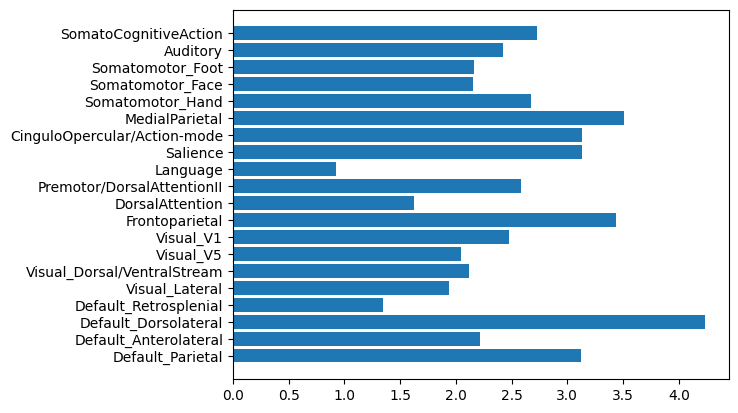

In [284]:
plt.barh(network_labels[:-1], zcs.sum(axis=0))

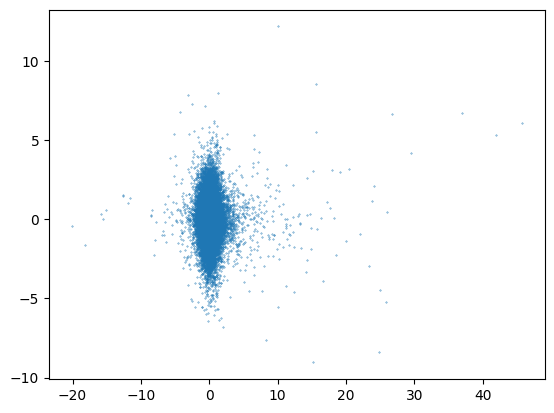

In [285]:
plt.scatter(*dt[:2], s=0.1)